In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

In [4]:
people = fetch_lfw_people(
    min_faces_per_person=20,
    resize=0.7
)

print("Data shape:", people.data.shape)
print("Target shape:", people.target.shape)

Data shape: (3023, 5655)
Target shape: (3023,)


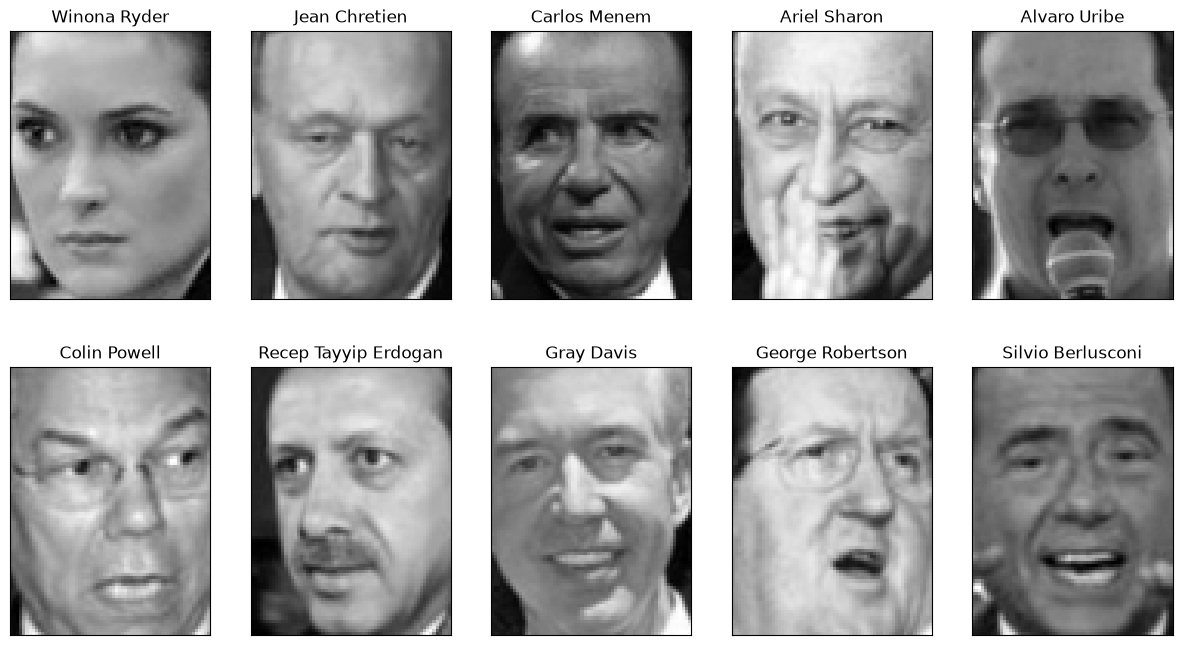

In [5]:
image_shape = people.images[0].shape

fig, axes = plt.subplots(
    2, 5,
    figsize=(15, 8),
    subplot_kw={'xticks': (), 'yticks': ()}
)

for target, image, ax in zip(
    people.target,
    people.images,
    axes.ravel()
):
    ax.imshow(image, cmap='gray')
    ax.set_title(people.target_names[target])

plt.show()

In [6]:
print("Image shape:", people.images.shape)
print("Number of classes:", len(people.target_names))

Image shape: (3023, 87, 65)
Number of classes: 62


In [7]:
X = people.data / 255.0
y = people.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3023, 5655)
y shape: (3023,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=20,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2418, 5655)
Testing data: (605, 5655)


In [9]:
model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=100,
    random_state=20
)

print(model)

MLPClassifier(max_iter=100, random_state=20)


In [10]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


C:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [11]:
print("people.images.shape: {}".format(people.images.shape))
print("Number of classes: {}".format(len(people.target_names)))

people.images.shape: (3023, 87, 65)
Number of classes: 62


In [12]:
counts = np.bincount(people.target)

for i, (count, name) in enumerate(
    zip(counts, people.target_names)
):
    print("{0:25} {1:3}".format(name, count), end='   ')

    if (i + 1) % 3 == 0:
        print()

Alejandro Toledo           39   Alvaro Uribe               35   Amelie Mauresmo            21   
Andre Agassi               36   Angelina Jolie             20   Ariel Sharon               77   
Arnold Schwarzenegger      42   Atal Bihari Vajpayee       24   Bill Clinton               29   
Carlos Menem               21   Colin Powell              236   David Beckham              31   
Donald Rumsfeld           121   George Robertson           22   George W Bush             530   
Gerhard Schroeder         109   Gloria Macapagal Arroyo    44   Gray Davis                 26   
Guillermo Coria            30   Hamid Karzai               22   Hans Blix                  39   
Hugo Chavez                71   Igor Ivanov                20   Jack Straw                 28   
Jacques Chirac             52   Jean Chretien              55   Jennifer Aniston           21   
Jennifer Capriati          42   Jennifer Lopez             21   Jeremy Greenstock          24   
Jiang Zemin                20 

In [13]:
dtype=np.bool

In [14]:
mask = np.zeros(people.target.shape, dtype=bool)

for target in np.unique(people.target):
    mask[np.where(people.target == target)[0][:50]] = 1

X_people = people.data[mask]
y_people = people.target[mask]

In [15]:
X_people = X_people / 255.0

print(X_people.shape)
print(y_people.shape)

(2063, 5655)
(2063,)


In [16]:
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_people,
    y_people,
    stratify=y_people,
    random_state=0
)

knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train, y_train)

print(
    "Test set score of 1-nn: {:.2f}".format(
        knn.score(X_test, y_test)
    )
)

Test set score of 1-nn: 0.22


In [18]:
from sklearn.decomposition import PCA

In [19]:
pca = PCA(n_components=100, whiten=True, random_state=0).fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print("X_train_pca.shape: {}".format(X_train_pca.shape))

X_train_pca.shape: (1547, 100)


In [20]:
pca = PCA(n_components=100, whiten=True, random_state=0).fit(X_train)

In [21]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [22]:
print("X_train_pca.shape:", X_train_pca.shape)

X_train_pca.shape: (1547, 100)


In [23]:
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train_pca, y_train)

print(
    "Test set accuracy: {:.2f}".format(
        knn.score(X_test_pca, y_test)
    )
)

Test set accuracy: 0.30


In [24]:
print(
    "pca.components_.shape: {}".format(
        pca.components_.shape
    )
)

pca.components_.shape: (100, 5655)


In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Train
X_train_scaled = scaler.fit_transform(X_train)

# Test
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (1547, 5655)
Testing data shape: (516, 5655)


In [27]:
print("Minimum value:", X_train_scaled.min())
print("Maximum value:", X_train_scaled.max())

Minimum value: 0.0
Maximum value: 1.0000001


In [28]:
X_test_scaled = scaler.fit_transform(X_test.astype(int))

In [29]:
X_test_scaled = scaler.transform(X_test)